# Parte 1: Análise Exploratória com APIs Externas

Esta seção cruza os chamados do 1746 (2023-2024) com dados climáticos da Open-Meteo e feriados nacionais para investigar como o volume de chamados responde a condições ambientais, padrões territoriais e eventos especiais.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import folium
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from shapely import wkt as shapely_wkt
from shapely.geometry import mapping



sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
pathlib.Path('../results/figures').mkdir(parents=True, exist_ok=True)

In [2]:
from src.collectors import DataPipeline

pipeline = DataPipeline(
    billing_project_id="desafio-pic-ds-494517",
    start_date="2023-01-01",
    end_date="2024-12-31",
)

dados = pipeline.run()

=== Coletando chamados do 1746 ===
[ChamadosCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\chamados.parquet

=== Coletando dados mestres ===
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\bairro.parquet
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\area_planejamento.parquet
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\regiao_administrativa.parquet
[DadosMestresCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\subprefeitura.parquet

=== Coletando dados climáticos ===
[OpenMeteoCollector] Carregando de C:\Users\marie\Documents\desafio-cientista-dados-senior-cidadaos-vulneraveis\data\raw\clima.parquet

=== Coletando feriados ===
[Public

In [3]:
df          = dados['chamados']
clima       = dados['clima']
feriados    = dados['feriados']
bairro      = dados['bairro']
regiao_adm  = dados['regiao_administrativa']
area_plan   = dados['area_planejamento']

# Normaliza data_inicio para dia (sem hora) — base para todos os agrupamentos
df = df.copy()
df['data'] = df['data_inicio'].dt.normalize()

print(f"Chamados: {len(df):,} | Clima: {len(clima):,} dias | Feriados: {len(feriados):,}")

Chamados: 2,792,446 | Clima: 731 dias | Feriados: 29


## 1. Clima e Demanda de Serviços

A hipótese de partida é que condições climáticas alteram o padrão de mobilidade e exposição dos moradores, o que deve se refletir em categorias específicas de chamados. Como o período inclui feriados e eventos climáticos extremos que criam dias atípicos, a análise usa correlação de Spearman, mais robusta a esses outliers.

In [4]:
# Agrupamento diário total e join com clima
diario = (
    df.groupby('data')
    .size()
    .reset_index(name='volume')
    .merge(clima, on='data', how='left')
)

# Features temporais — necessárias para interpretar correlações (dia da semana confunde)
diario['dia_semana']  = diario['data'].dt.dayofweek
diario['mes']         = diario['data'].dt.month
diario['ano']         = diario['data'].dt.year
diario['fim_semana']  = (diario['dia_semana'] >= 5).astype(int)
diario['feriado']     = diario['data'].dt.date.isin(feriados['data'].dt.date).astype(int)

print(diario.shape)
diario.head(3)

(731, 12)


,data,volume,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,dia_semana,mes,ano,fim_semana,feriado
0,2023-01-01,730,28.0,22.2,24.8,2.8,15.3,6,1,2023,1,1
1,2023-01-02,4254,29.4,21.0,25.7,0.0,14.1,0,1,2023,0,0
2,2023-01-03,4437,32.8,23.4,27.5,2.0,15.1,1,1,2023,0,0


In [5]:
VARS_CLIMA = ['temperature_2m_max', 'temperature_2m_min',
              'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max']

# Correlação de Spearman: volume total vs variáveis climáticas
corr_total = (
    diario[['volume'] + VARS_CLIMA]
    .corr(method='spearman')['volume']
    .drop('volume')
    .rename({
        'temperature_2m_max':  'Temp. máx.',
        'temperature_2m_min':  'Temp. mín.',
        'temperature_2m_mean': 'Temp. média',
        'precipitation_sum':   'Precipitação',
        'wind_speed_10m_max':  'Vento máx.',
    })
)

print(corr_total.sort_values())

Precipitação   -0.028299
Vento máx.     -0.008721
Temp. máx.      0.220736
Temp. mín.      0.251626
Temp. média     0.267027
Name: volume, dtype: float64


In [6]:
# Correlação de Spearman por categoria — todas as variáveis climáticas
diario_cat = (
    df.groupby(['data', 'categoria'])
    .size()
    .reset_index(name='volume')
    .merge(clima, on='data', how='left')
)

corr_cat = {}
for cat, sub in diario_cat.groupby('categoria'):
    corr_cat[cat] = {
        'Precipitação': sub['volume'].corr(sub['precipitation_sum'],   method='spearman'),
        'Temp. máx.':   sub['volume'].corr(sub['temperature_2m_max'],  method='spearman'),
        'Temp. mín.':   sub['volume'].corr(sub['temperature_2m_min'],  method='spearman'),
        'Temp. média':  sub['volume'].corr(sub['temperature_2m_mean'], method='spearman'),
        'Vento máx.':   sub['volume'].corr(sub['wind_speed_10m_max'],  method='spearman'),
    }

corr_cat_df = pd.DataFrame(corr_cat).T.round(3)
print(corr_cat_df.sort_values('Temp. máx.', ascending=False))


             Precipitação  Temp. máx.  Temp. mín.  Temp. média  Vento máx.
Serviço            -0.057       0.247       0.265        0.293      -0.054
Informações         0.006       0.125       0.155        0.155       0.043
Reclamação          0.025       0.112       0.210        0.193      -0.130
Sugestão           -0.225       0.107      -0.084        0.005       0.091
Denúncia           -0.062       0.062       0.049        0.057       0.042
Elogio             -0.102       0.036      -0.025        0.007       0.008
Crítica            -0.224       0.033      -0.153       -0.070       0.052


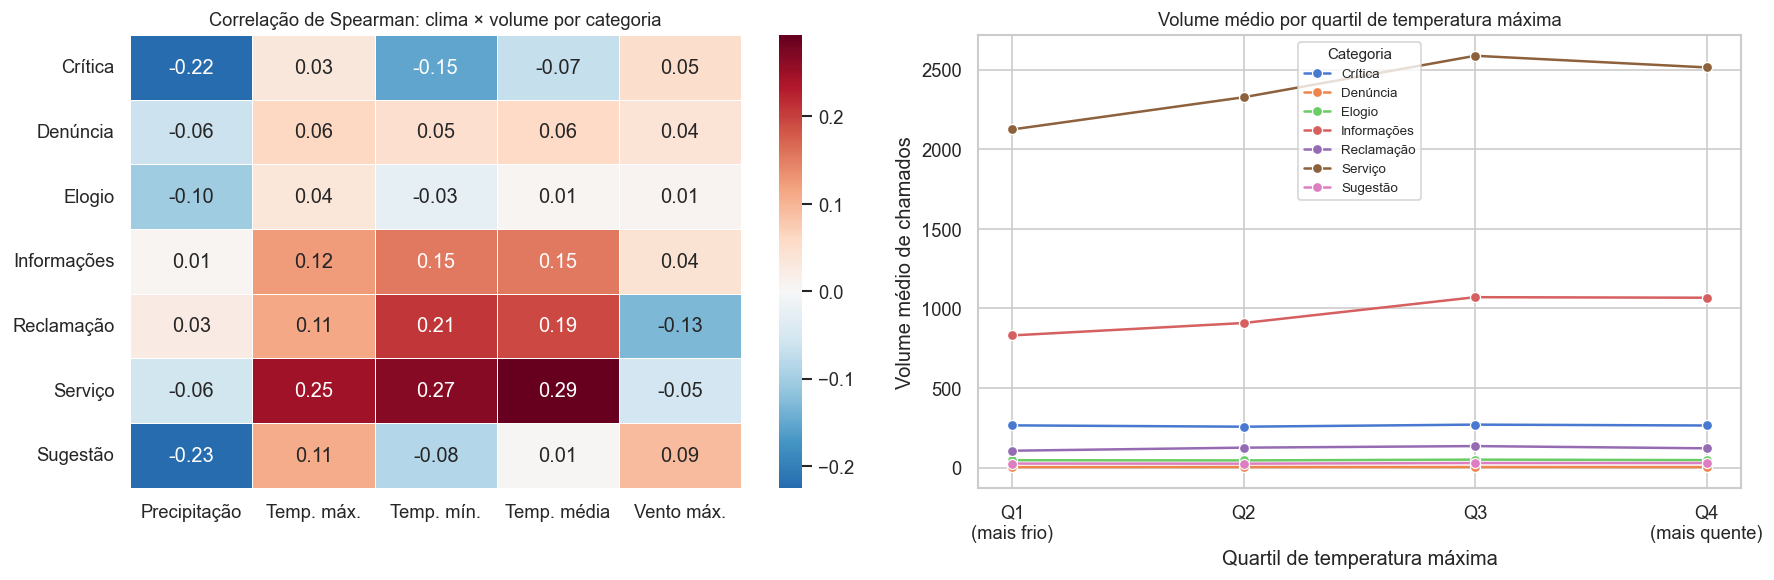

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Painel 1: heatmap com todas as variáveis climáticas por categoria
sns.heatmap(
    corr_cat_df,
    annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Correlação de Spearman: clima × volume por categoria', fontsize=11)
axes[0].set_xlabel('')

# Painel 2: volume médio por quartil de temperatura, por categoria
diario_cat['quartil_temp'] = pd.qcut(
    diario_cat['temperature_2m_max'], q=4,
    labels=['Q1\n(mais frio)', 'Q2', 'Q3', 'Q4\n(mais quente)']
)

media_cat_temp = (
    diario_cat
    .groupby(['quartil_temp', 'categoria'], observed=True)['volume']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=media_cat_temp,
    x='quartil_temp', y='volume',
    hue='categoria', marker='o',
    ax=axes[1]
)
axes[1].set_title('Volume médio por quartil de temperatura máxima', fontsize=11)
axes[1].set_xlabel('Quartil de temperatura máxima')
axes[1].set_ylabel('Volume médio de chamados')
axes[1].legend(title='Categoria', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/q1_clima_demanda.png', bbox_inches='tight')
plt.show()


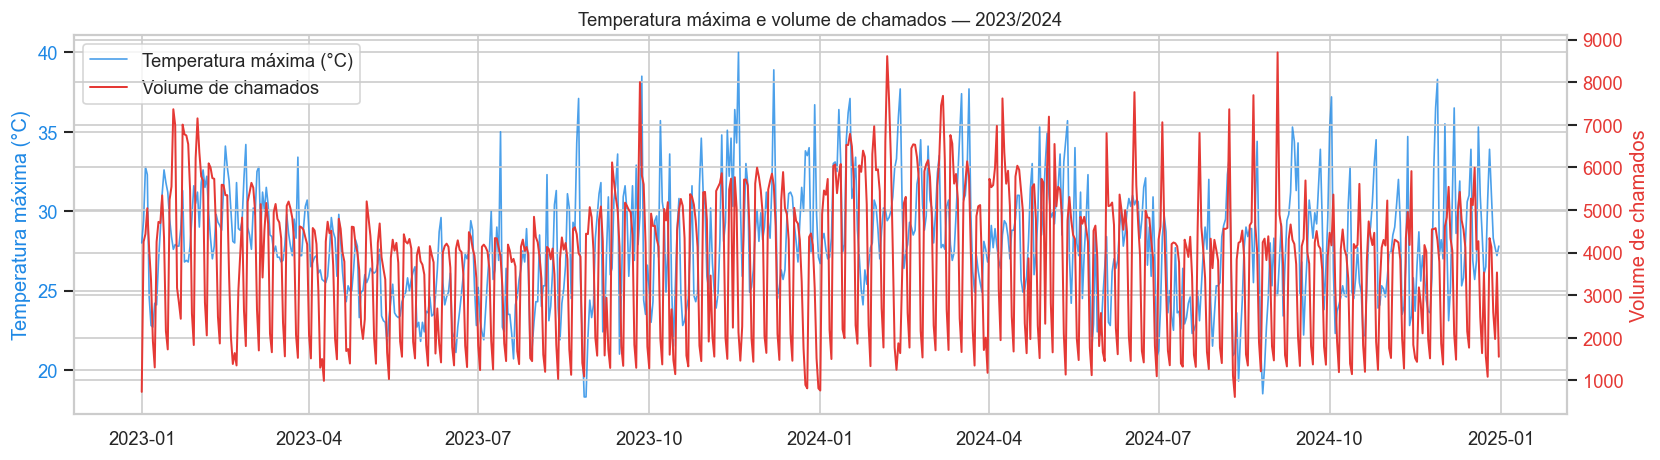

In [8]:
# Série temporal: volume diário sobreposto com temperatura máxima (2023/2024)
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(diario['data'], diario['temperature_2m_max'], color='#1E88E5',
         linewidth=1.0, alpha=0.8, label='Temperatura máxima (°C)')
ax1.set_ylabel('Temperatura máxima (°C)', color='#1E88E5')
ax1.tick_params(axis='y', labelcolor='#1E88E5')

ax2 = ax1.twinx()
ax2.plot(diario['data'], diario['volume'], color='#E53935', linewidth=1.2, label='Volume de chamados')
ax2.set_ylabel('Volume de chamados', color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Temperatura máxima e volume de chamados — 2023/2024', fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/q1_serie_temporal.png', bbox_inches='tight')
plt.show()


**Interpretação.** A variável climática com sinal mais claro é temperatura, não precipitação. A correlação de Spearman entre temperatura máxima e volume total é 0.22, enquanto precipitação fica em -0.03, essencialmente zero.

Por categoria, Serviço é a mais sensível ao clima: correlação de 0.25 com temperatura máxima e 0.27 com temperatura mínima. O gráfico de volume médio por quartil de temperatura confirma esse padrão, com Serviço crescendo de forma consistente do quartil mais frio para o mais quente. Reclamação segue o mesmo sentido, com correlações menores (0.11 a 0.21). Informações também cresce com temperatura, o que pode refletir maior atividade urbana em dias quentes gerando mais consultas.

Com precipitação, o sinal vai na direção oposta: Crítica (-0.22) e Sugestão (-0.23) têm as correlações negativas mais fortes, sugerindo que chuva intensa reduz a exposição aos problemas urbanos que geram esses chamados. Essa interpretação é consistente com o fato de que dias de chuva forte são raríssimos no período (apenas 1 dia acima de 50mm).

## 2. Padrões Geoespaciais de Demanda

Os chamados do 1746 têm origem distribuída por todo o território do Rio, mas a distribuição não é uniforme. Esta seção investiga se há concentração em determinadas regiões, se as categorias de chamados variam por território e o que esses padrões dizem sobre a demanda por serviços públicos na cidade.

In [9]:
df_regiao = (
    df.dropna(subset=['id_bairro'])
    .merge(
        bairro[['id_bairro', 'id_regiao_administrativa',
                'nome_regiao_administrativa', 'id_area_planejamento']],
        on='id_bairro', how='left'
    )
    .rename(columns={'nome_regiao_administrativa': 'regiao'})
)

print(f"Cobertura geoespacial: {len(df_regiao) / len(df) * 100:.1f}% dos chamados")
print(f"Regiões únicas: {df_regiao['regiao'].nunique()}")
print(f"Áreas de planejamento: {df_regiao['id_area_planejamento'].nunique()}")


Cobertura geoespacial: 68.5% dos chamados
Regiões únicas: 33
Áreas de planejamento: 5


In [10]:
por_regiao = (
    df_regiao
    .groupby('regiao')
    .size()
    .reset_index(name='volume')
    .sort_values('volume', ascending=False)
)
print(por_regiao.head(10).to_string(index=False))


         regiao  volume
   Campo Grande  193598
    Jacarepagua  167427
          Meier  157249
      Madureira  126817
Barra Da Tijuca  112716
       Botafogo  100504
     Santa Cruz   95101
          Bangu   88415
         Tijuca   73656
    Vila Isabel   69234


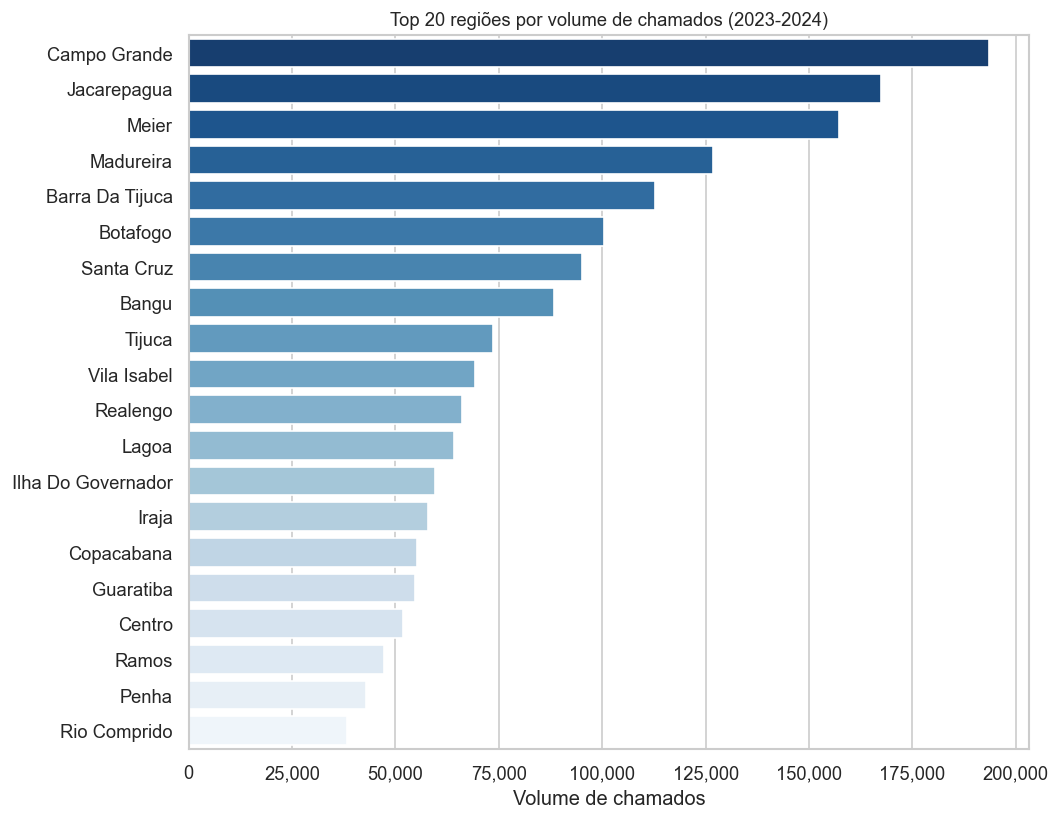

Mapa salvo em results/figures/q2_mapa_volume.html


In [11]:
# Bar chart
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=por_regiao.head(20), y='regiao', x='volume',
            palette='Blues_r', ax=ax)
ax.set_title('Top 20 regiões por volume de chamados (2023-2024)', fontsize=11)
ax.set_xlabel('Volume de chamados')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../results/figures/q2_concentracao_regioes.png', bbox_inches='tight')
plt.show()

# Mapa coroplético de volume
features = []
for _, row in regiao_adm.iterrows():
    geom = shapely_wkt.loads(row['geometry_wkt'])
    features.append({
        "type": "Feature",
        "properties": {"nome": row['nome']},
        "geometry": mapping(geom)
    })
geo_json = {"type": "FeatureCollection", "features": features}

def normalizar(s):
    return (unicodedata.normalize('NFKD', str(s))
            .encode('ascii', 'ignore').decode('ascii').upper().strip())

CORRECOES = {'SANTA TEREZA': 'SANTA TERESA'}
def chave(s):
    n = normalizar(s)
    return CORRECOES.get(n, n)

for f in features:
    f['properties']['chave'] = chave(f['properties']['nome'])
por_regiao['chave'] = por_regiao['regiao'].apply(chave)

m_vol = folium.Map(location=[-22.9068, -43.1729], zoom_start=11,
                   tiles='CartoDB positron')
folium.Choropleth(
    geo_data=geo_json, data=por_regiao,
    columns=['chave', 'volume'], key_on='feature.properties.chave',
    fill_color='YlOrRd', fill_opacity=0.7, line_opacity=0.2,
    legend_name='Volume de chamados (2023-2024)', highlight=True,
).add_to(m_vol)
folium.GeoJson(
    geo_json,
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(fields=['nome'], aliases=['Região:']),
).add_to(m_vol)
m_vol.save('../results/figures/q2_mapa_volume.html')
print('Mapa salvo em results/figures/q2_mapa_volume.html')


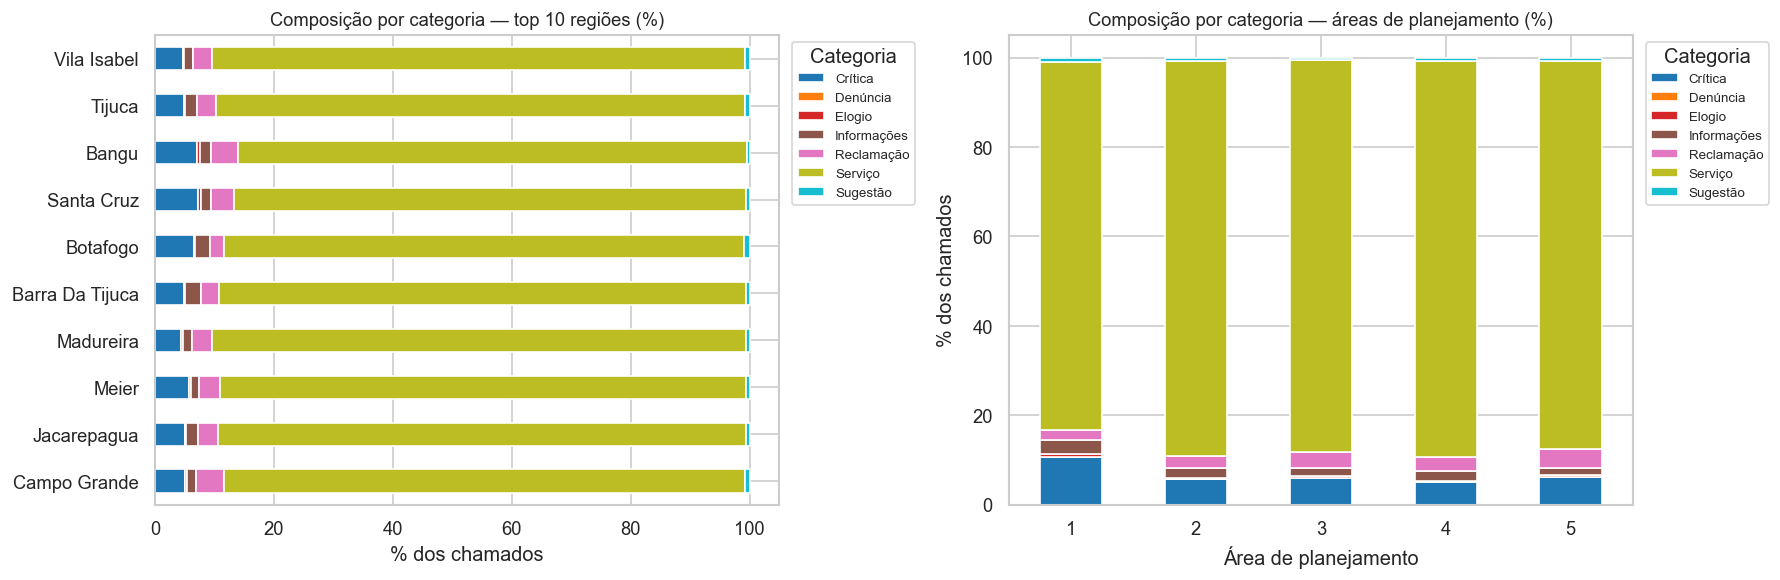

In [12]:
por_reg_cat = (
    df_regiao
    .groupby(['regiao', 'categoria'])
    .size()
    .reset_index(name='volume')
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar por região (top 10)
top10 = por_regiao.head(10)['regiao'].tolist()
pivot_reg = (
    por_reg_cat[por_reg_cat['regiao'].isin(top10)]
    .pivot_table(index='regiao', columns='categoria', values='volume', fill_value=0)
    .loc[top10]
)
pivot_reg_pct = pivot_reg.div(pivot_reg.sum(axis=1), axis=0) * 100
pivot_reg_pct.plot(kind='barh', stacked=True, ax=axes[0], colormap='tab10')
axes[0].set_title('Composição por categoria — top 10 regiões (%)', fontsize=11)
axes[0].set_xlabel('% dos chamados')
axes[0].set_ylabel('')
axes[0].legend(title='Categoria', bbox_to_anchor=(1.01, 1),
               loc='upper left', fontsize=8)

# Stacked bar por área de planejamento
por_ap_cat = (
    df_regiao
    .groupby(['id_area_planejamento', 'categoria'])
    .size()
    .reset_index(name='volume')
)
pivot_ap = (
    por_ap_cat
    .pivot_table(index='id_area_planejamento', columns='categoria',
                 values='volume', fill_value=0)
)
pivot_ap_pct = pivot_ap.div(pivot_ap.sum(axis=1), axis=0) * 100
pivot_ap_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Composição por categoria — áreas de planejamento (%)', fontsize=11)
axes[1].set_xlabel('Área de planejamento')
axes[1].set_ylabel('% dos chamados')
axes[1].legend(title='Categoria', bbox_to_anchor=(1.01, 1),
               loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/q2_categorias_territorio.png', bbox_inches='tight')
plt.show()


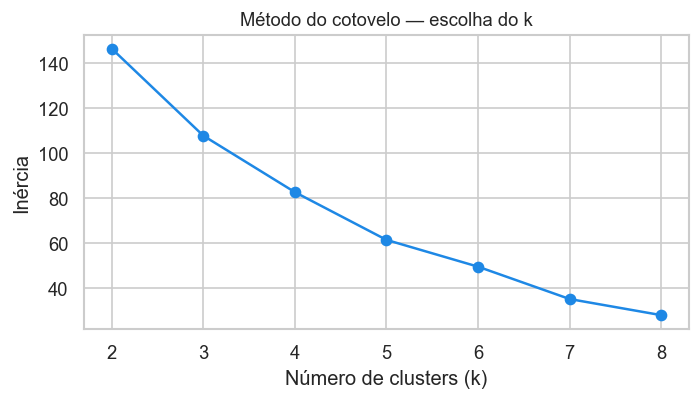

Perfil médio por cluster (proporção de cada categoria):
categoria  Crítica  Denúncia  Elogio  Informações  Reclamação  Serviço  Sugestão
cluster                                                                         
0            0.059     0.000   0.004        0.019       0.034    0.878     0.007
1            0.144     0.000   0.022        0.027       0.029    0.770     0.009
2            0.181     0.004   0.011        0.018       0.035    0.751     0.001

Cluster 0: Anchieta, Bangu, Barra Da Tijuca, Botafogo, Campo Grande, Centro, Copacabana, Guaratiba, Ilha Do Governador, Inhauma, Iraja, Jacarepagua, Lagoa, Madureira, Meier, Paqueta, Penha, Portuaria, Ramos, Realengo, Santa Cruz, Santa Tereza, Tijuca, Vigario Geral, Vila Isabel
Cluster 1: Cidade De Deus, Complexo Da Mare, Complexo Do Alemão, Jacarezinho, Pavuna, Rio Comprido, Sao Cristovao
Cluster 2: Rocinha


In [13]:
# Perfil de cada região: proporção de chamados por categoria
pivot_cluster = (
    df_regiao
    .groupby(['regiao', 'categoria'])
    .size()
    .reset_index(name='volume')
    .pivot_table(index='regiao', columns='categoria', values='volume', fill_value=0)
)
pivot_pct = pivot_cluster.div(pivot_cluster.sum(axis=1), axis=0)
X = StandardScaler().fit_transform(pivot_pct)

# Método do cotovelo: inércia vs k para escolha fundamentada do número de clusters
inercias = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ks, inercias, marker='o', color='#1E88E5')
ax.set_title('Método do cotovelo — escolha do k', fontsize=11)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inércia')
plt.tight_layout()
plt.savefig('../results/figures/q2_elbow.png', bbox_inches='tight')
plt.show()

# K-means com k=3: maior ganho de homogeneidade ocorre na passagem de k=2->3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pivot_pct = pivot_pct.copy()
pivot_pct['cluster'] = kmeans.fit_predict(X)

# Perfil médio por cluster
perfil = pivot_pct.groupby('cluster').mean().drop(columns='cluster', errors='ignore')

print('Perfil médio por cluster (proporção de cada categoria):')
print(perfil.round(3).to_string())
print()
for c in sorted(pivot_pct['cluster'].unique()):
    regioes = pivot_pct[pivot_pct['cluster'] == c].index.tolist()
    print(f"Cluster {c}: {', '.join(regioes)}")


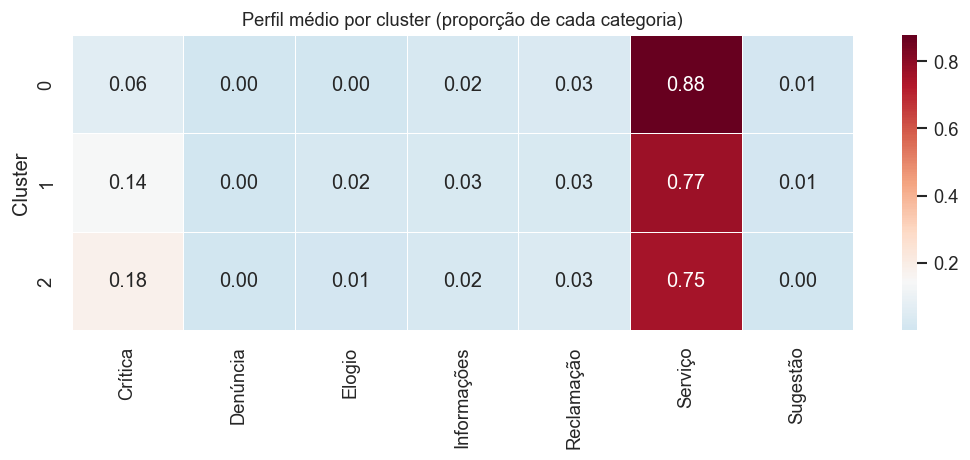

Mapa de clusters salvo em results/figures/q2_mapa_clusters.html


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    perfil, annot=True, fmt='.2f', center=perfil.mean().mean(),
    cmap='RdBu_r', linewidths=0.5, ax=ax
)
ax.set_title('Perfil médio por cluster (proporção de cada categoria)', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../results/figures/q2_perfil_clusters.png', bbox_inches='tight')
plt.show()

# Mapa colorido por cluster
cluster_map_dict = {
    chave(regiao): int(cluster)
    for regiao, cluster in pivot_pct['cluster'].items()
}

cores_cluster = {0: '#E53935', 1: '#1E88E5', 2: '#43A047'}

def style_cluster(feature):
    chave_regiao = feature['properties']['chave']
    cluster_id = cluster_map_dict.get(chave_regiao, -1)
    return {
        'fillColor': cores_cluster.get(cluster_id, '#cccccc'),
        'fillOpacity': 0.7,
        'weight': 0.5,
        'color': 'white'
    }

m_cluster = folium.Map(location=[-22.9068, -43.1729], zoom_start=11,
                       tiles='CartoDB positron')
folium.GeoJson(
    geo_json,
    style_function=style_cluster,
    tooltip=folium.GeoJsonTooltip(fields=['nome'], aliases=['Região:'])
).add_to(m_cluster)
m_cluster.save('../results/figures/q2_mapa_clusters.html')
print('Mapa de clusters salvo em results/figures/q2_mapa_clusters.html')


**Interpretação.** A demanda não se distribui uniformemente pelo território: as regiões com maior volume absoluto tendem a ser as mais populosas ou com maior concentração de infraestrutura urbana degradada. A composição por categoria também varia, e o agrupamento por perfil de demanda (curva de inércia não apresenta cotovelo nítido, mas o maior ganho de homogeneidade ocorre na passagem de k=2 para k=3) revela três grupos territoriais distintos.

O cluster majoritário (25 regiões) concentra a maior proporção de "Serviço" (~88%), incluindo tanto bairros de renda média como periferias com alta demanda operacional. O segundo grupo (7 regiões — Complexo da Maré, Complexo do Alemão, Jacarezinho, Cidade de Deus, entre outros) apresenta perfil ligeiramente mais diversificado, com proporção de "Crítica" e "Elogio" acima da média. Rocinha forma um cluster isolado, com a maior proporção de "Crítica" do conjunto (18%).

**Limitação.** O volume absoluto por região não controla pela população residente. Uma análise mais rigorosa exigiria normalizar por habitantes (IBGE), o que permitiria distinguir alta demanda por concentração populacional de alta demanda por piores condições de serviço.